# Figure 5: Mixed vs. Blocked SNR

Translation of `Figure05_mixedVsBlockedSNR.m`

## What this notebook does

Compares how participants' decision bounds relate to SNR in two task variants:

- **OL (Blocked SNR)**: Each block contains only one SNR level; subjects know which SNR applies.
- **MX (Mixed SNR)**: Multiple SNR levels are interleaved within a block; subjects must infer the SNR.

The hypothesis: in mixed SNR, subjects cannot set SNR-specific bounds, so low-SNR and high-SNR
bounds should be more similar than in blocked SNR.

**2 × 2 figure layout** (rows = OL / MX, columns = two analyses):

- **Left column**: Reward-rate heatmap (coins per trial vs. lo × hi SNR bound pair), with per-subject
  mean bounds overlaid as open circles. Generated by simulating the task over a grid of bound pairs
  (`RR_BOUNDS`, 16 values). Shows whether subjects are near the reward-maximising bound combination.
  The optimal point is marked with a red cross; the near-optimal region (≥95 % of max RR) with black
  crosses. Wilcoxon signed-rank test (lo vs. hi bound per subject) reported in the panel title.
- **Right column**: Hi − Lo SNR bound difference per DT bin (1–10 steps); individual points shown in
  light grey, group mean as a red circle (filled if Wilcoxon p < 0.05 vs. 0, open otherwise).

**Data**: Block 2 (penalty block), pre-filtered to `DT > 2` (keeps DT ≥ 3), all subjects.

## Imports

Standard scientific Python libraries plus `get_data_table`, `get_bound_summary`, and
`get_simulated_data_table`. No data loading or analysis here.

## Load data

Loads both task variants:
- `data_table_mx`: Mixed-SNR (MX) task — multiple SNR levels interleaved within each block.
- `data_table_ol`: Open-loop / Blocked-SNR (OL) task — one SNR level per block.

Both calls apply internal processing: bound/DT computation, wall-hit marking, bias correction,
and block merging (6 → 3 blocks). No trials are dropped at this stage.

## Parameters and RR-matrix computation

**`MIN_DT`**: Pre-filter applied before `get_bound_summary`; keeps DT ≥ 3 (matching MATLAB `minDT=2`).

**`RR_BOUNDS`**: Bound grid used for the reward-rate simulation (0.01 to 0.80 in steps of 0.05, 16
values — matching MATLAB `rrBounds = 0.01:0.05:0.8`).

**`NUM_RR_REPS`**: Number of simulated subjects per condition (matching MATLAB `numRRReps=100`).

**`G_MEANS`**: Generative means for lo and hi SNR (matching MATLAB defaults `[0.05 0.15]`).

**`COMPUTE_RR`**: Set to `False` to skip the reward-rate simulation and show only the scatter overlay.
The simulation takes ~1 min for OL and ~15 min for MX on a standard laptop.

**`get_bound_summary` internal filters** (via `get_good_trial_array`):
- `DT ≥ 1`, `trial_number ≥ 10`, `bound` finite and non-zero, `correct ≥ 0`, `wall_hit = False`.

**Data included per task**: All subjects, block 2 only, all SNR levels (sorted ascending: index 0 =
lo SNR, index −1 = hi SNR).

**Data excluded**: Subjects with fewer than 2 valid SNR levels (panel skipped with a message).
DT bins where fewer than 3 subjects have data for both SNR levels (omitted from the right column).

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats

from pigeon.data import get_data_table
from pigeon.stats import get_bound_summary
from pigeon.simulate import get_simulated_data_table
from pigeon.pathDefaults import FIGURES_DIR

In [2]:
data_table_mx = get_data_table(task_type='MX')
data_table_ol = get_data_table(task_type='OL')

  1: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_MX/prolificcsvs/PigeonTask_2022-11-23_09h13.45.625.csv
  2: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_MX/prolificcsvs/PigeonTask_2022-11-23_10h11.56.537.csv
  3: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_MX/prolificcsvs/PigeonTask_2022-11-23_10h12.28.806.csv
  4: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_MX/prolificcsvs/PigeonTask_2022-11-23_10h13.05.149.csv
  5: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_MX/prolificcsvs/PigeonTask_2022-11-23_10h13.09.605.csv
  6: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_MX/prolificcsvs/PigeonTask_2022-11-23_10h13.30.507.csv
  7: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_MX/prolificcsvs/PigeonTask_2022-11-23_10h13.32.506.csv
  8: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pi

Computing RR matrix for OL...
  OL RR matrix: bound 16/16
  Done: OL
Computing RR matrix for MX...
  MX RR matrix: lo-bound 16/16
  Done: MX


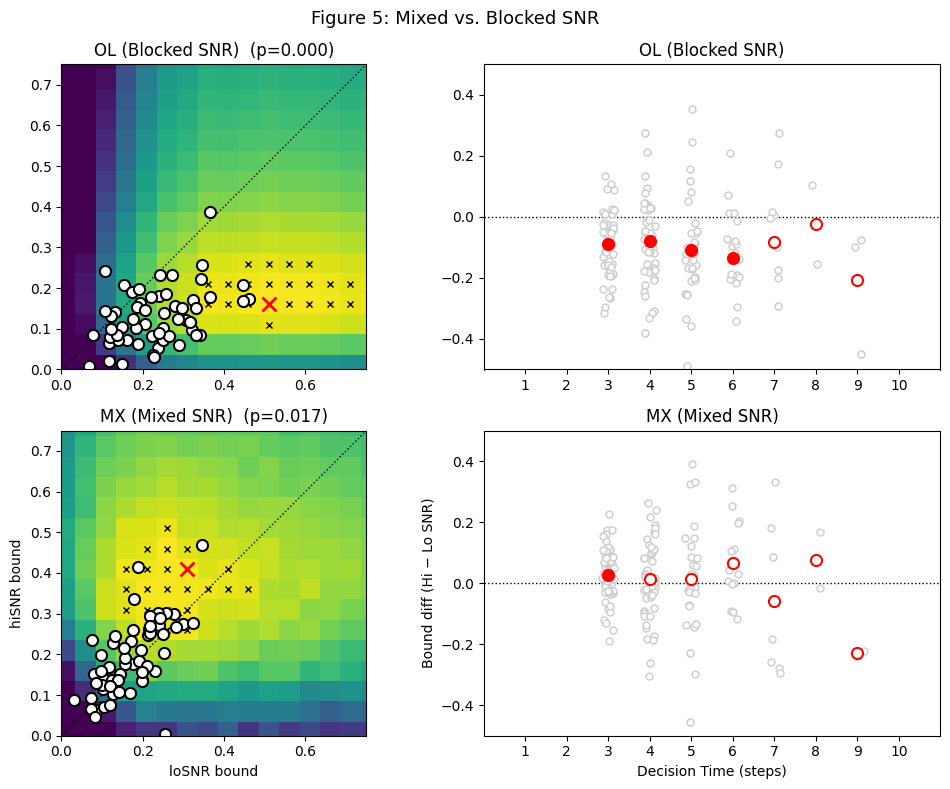

In [3]:
# ── Parameters (matching MATLAB Figure05 defaults) ────────────────────────────
MIN_DT      = 2                         # keep DT > MIN_DT (i.e. DT ≥ 3)
BLOCK       = 2                         # block 2 = penalty block
MAX_RT      = 10                        # number of DT bins (1..MAX_RT)
RR_BOUNDS   = np.arange(0.01, 0.81, 0.05)  # bound grid: 0.01:0.05:0.8 (16 values)
NUM_RR_REPS = 100                       # simulated subjects per condition
G_MEANS     = [0.05, 0.15]             # lo and hi SNR generative means
COMPUTE_RR  = True                      # False = skip slow simulation

rng = np.random.default_rng(42)


# ── Helper: simulate reward-rate matrix ───────────────────────────────────────
def compute_rr_matrix(task_type, block, rr_bounds, num_reps, g_means, rng):
    """Compute expected reward rate over a lo-SNR-bound × hi-SNR-bound grid.

    Returns rr_matrix[lo_idx, hi_idx] = mean total coins per subject, matching
    MATLAB's RRMatrix_(b1, b2) convention where b1=lo-bound index, b2=hi-bound
    index (outer loop = lo, inner loop = hi).

    For OL (blocked SNR): lo and hi SNR blocks are simulated separately for each
    bound value. Their mean coin counts are added, matching MATLAB's accumulation:
        RRMatrix_(:, b1) += mean(loCoinCounts)   [column b1 = lo-bound]
        RRMatrix_(b1, :) += mean(hiCoinCounts)   [row b1 = hi-bound]
    → rr_matrix[hi_idx, lo_idx]

    For MX (mixed SNR): each (lo_bound, hi_bound) pair requires its own
    simulation with both SNR levels interleaved, matching MATLAB's loop over
    (b1=lo, b2=hi) with boundType='varBySNR'.
    → rr_matrix[lo_idx, hi_idx]
    """
    n = len(rr_bounds)
    rr_matrix = np.zeros((n, n))
    specs = {'num_subjects': num_reps, 'blocks': [block]}

    if task_type == 'OL':
        # OL: rr_matrix[hi_idx, lo_idx] — matches MATLAB RRMatrix_(hi_row, lo_col)
        for b1, bnd in enumerate(rr_bounds):
            print(f'  OL RR matrix: bound {b1 + 1}/{n}', end='\r')

            # Low-SNR block: bound = bnd, generative_mean = g_means[0]
            lo_table = get_simulated_data_table(
                specs=specs, generative_mean=g_means[0],
                bound_mean=bnd, correct_bias=None, rng=rng)
            lo_coins = lo_table.groupby('subject_index')['coin_count'].last().mean()

            # High-SNR block: bound = bnd, generative_mean = g_means[1]
            hi_table = get_simulated_data_table(
                specs=specs, generative_mean=g_means[1],
                bound_mean=bnd, correct_bias=None, rng=rng)
            hi_coins = hi_table.groupby('subject_index')['coin_count'].last().mean()

            # lo bound = b1 → entire column b1; hi bound = b1 → entire row b1
            rr_matrix[:, b1] += lo_coins
            rr_matrix[b1, :] += hi_coins

    else:  # MX
        # MX: rr_matrix[lo_idx, hi_idx] — matches MATLAB RRMatrix_(b1=lo, b2=hi)
        for b1, lo_bnd in enumerate(rr_bounds):
            print(f'  MX RR matrix: lo-bound {b1 + 1}/{n}', end='\r')
            for b2, hi_bnd in enumerate(rr_bounds):
                # Mixed block: both SNRs interleaved; lo SNR gets lo_bnd, hi SNR gets hi_bnd.
                # Passing generative_mean as a list and bound_mean as a matching list causes
                # simulate_trials to assign bounds per-SNR (equivalent to MATLAB's varBySNR).
                mx_table = get_simulated_data_table(
                    specs=specs,
                    generative_mean=list(g_means),
                    bound_mean=[lo_bnd, hi_bnd],
                    correct_bias=None, rng=rng)
                rr_matrix[b1, b2] = (
                    mx_table.groupby('subject_index')['coin_count'].last().mean())
    print()
    return rr_matrix


# ── Helper: populate one row of the 2×2 figure ───────────────────────────────
def _plot_row(axs_row, data_table, label, block, min_dt, max_rt,
              rr_bounds, rr_matrix, rng):
    """Draw left (RR heatmap + scatter) and right (per-DT bound diff) panels."""
    this_table = data_table[data_table['DT'] > min_dt].reset_index(drop=True)

    # Bound summaries — shape (n_subjects, 1, n_snrs, n_rt_bins, 3)
    bs_all    = get_bound_summary(this_table, blocks=[block], max_rt='all')
    bs_per_rt = get_bound_summary(this_table, blocks=[block], max_rt=max_rt)

    if bs_all.shape[2] < 2:
        for ax in axs_row:
            ax.set_title(f'{label}  — need ≥2 SNR levels')
            ax.axis('off')
        print(f'Skipping {label}: only {bs_all.shape[2]} SNR level(s) found')
        return

    lo = bs_all[:, 0,  0, 0, 0]   # mean abs bound, lo SNR, all DTs collapsed
    hi = bs_all[:, 0, -1, 0, 0]   # mean abs bound, hi SNR, all DTs collapsed

    # ── Left panel: RR heatmap with subject data overlaid ─────────────────────
    ax = axs_row[0]
    b0, b1 = rr_bounds[0], rr_bounds[-1]

    if rr_matrix is not None:
        ax.imshow(
            rr_matrix, origin='lower',
            extent=[b0 - 0.025, b1 + 0.025, b0 - 0.025, b1 + 0.025],
            aspect='auto', vmin=0, vmax=rr_matrix.max(), cmap='viridis')

        # Near-optimal region (≥95 % of max) — black crosses
        near_opt = rr_matrix >= 0.95 * rr_matrix.max()
        hi_idxs, lo_idxs = np.where(near_opt)
        ax.plot(rr_bounds[lo_idxs], rr_bounds[hi_idxs], 'kx', markersize=4)

        # Optimal point — red cross
        opt_hi, opt_lo = np.unravel_index(rr_matrix.argmax(), rr_matrix.shape)
        ax.plot(rr_bounds[opt_lo], rr_bounds[opt_hi], 'rx',
                markersize=10, markeredgewidth=2)

    ax.plot([0, 0.75], [0, 0.75], 'k:', linewidth=1)

    valid = np.isfinite(lo) & np.isfinite(hi)
    ax.plot(lo[valid], hi[valid], 'ko', markerfacecolor='white',
            markersize=8, markeredgewidth=1.5)
    ax.set_xlim(0, 0.75)
    ax.set_ylim(0, 0.75)
    ax.set_aspect('equal')

    if valid.sum() > 2:
        _, p = scipy.stats.wilcoxon(lo[valid], hi[valid])
        ax.set_title(f'{label}  (p={p:.3f})')
    else:
        ax.set_title(label)

    # ── Right panel: hi − lo SNR bound difference per DT bin ──────────────────
    ax = axs_row[1]
    rt_axis = np.arange(1, max_rt + 1)

    # diffs[subject, rt_bin] = hi-SNR bound − lo-SNR bound
    diffs = bs_per_rt[:, 0, -1, :, 0] - bs_per_rt[:, 0, 0, :, 0]
    n_lo  = bs_per_rt[:, 0,  0, :, 2]  # n_trials per subject per DT bin (lo SNR)
    n_hi  = bs_per_rt[:, 0, -1, :, 2]  # n_trials per subject per DT bin (hi SNR)

    ax.axhline(0, color='k', linestyle=':', linewidth=1)

    for di, dt in enumerate(rt_axis):
        col   = diffs[:, di]
        valid = np.isfinite(col) & (n_lo[:, di] >= 1) & (n_hi[:, di] >= 1)
        col_v = col[valid]
        col_v = col_v[np.isfinite(col_v)]

        if len(col_v) < 2:
            continue

        jitter = rng.uniform(-0.15, 0.15, size=len(col_v))
        ax.plot(dt + jitter, col_v, 'o', color='0.8',
                markerfacecolor='white', markersize=5, zorder=2)

        mean_diff = np.mean(col_v)
        _, p = scipy.stats.wilcoxon(col_v)
        face = 'red' if p < 0.05 else 'white'
        ax.plot(dt, mean_diff, 'ro', markerfacecolor=face,
                markersize=8, zorder=5, markeredgewidth=1.5)

    ax.set_xlim(0, max_rt + 1)
    ax.set_ylim(-0.5, 0.5)
    ax.set_xticks(rt_axis)
    ax.set_title(label)


# ── Compute RR matrices (stored for reuse in formatted-figure cell) ───────────
tasks = [
    (data_table_ol, 'OL (Blocked SNR)', 'OL'),
    (data_table_mx, 'MX (Mixed SNR)',   'MX'),
]
rr_matrices = {}

if COMPUTE_RR:
    for _, label, task_type in tasks:
        print(f'Computing RR matrix for {task_type}...')
        rr_matrices[task_type] = compute_rr_matrix(
            task_type, BLOCK, RR_BOUNDS, NUM_RR_REPS, G_MEANS, rng)
        print(f'  Done: {task_type}')


# ── Main 2×2 figure ───────────────────────────────────────────────────────────
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle('Figure 5: Mixed vs. Blocked SNR', fontsize=13)

for row_idx, (data_table, label, task_type) in enumerate(tasks):
    _plot_row(axs[row_idx], data_table, label, BLOCK, MIN_DT, MAX_RT,
              RR_BOUNDS, rr_matrices.get(task_type), rng)

# Labels on bottom row only (matches MATLAB: xlabel/ylabel only when tt==2)
axs[1, 0].set_xlabel('loSNR bound')
axs[1, 0].set_ylabel('hiSNR bound')
axs[1, 1].set_xlabel('Decision Time (steps)')
axs[1, 1].set_ylabel('Bound diff (Hi \u2212 Lo SNR)')

plt.tight_layout()
plt.show()

## Formatted figure

Reproduces the 2 × 2 figure at publication dimensions matching MATLAB's `getPLOT_axes` call:

```matlab
getPLOT_axes(5, 11.6, [4 4], {2,2}, 1.3, 1.5, [], 'Pigeons', true)
```

- **Width**: 11.6 cm (1.5 JNeurosci columns)
- **Row heights**: 4 cm each; vertical panel separation 1.3 cm; horizontal 1.5 cm
- **Font size**: 12 pt
- Saves to `Figure05_formatted.pdf`.

Reuses the RR matrices computed in the cell above (no re-simulation needed).

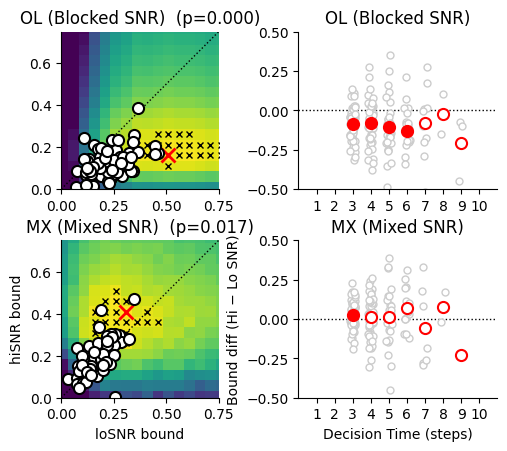

Saved /Users/jigold/Library/CloudStorage/Box-Box/GoldLab/Projects/2025_Pigeon/Figures/Figure05_formatted.pdf


In [4]:
# ── Publication-quality layout matching MATLAB getPLOT_axes(5, 11.6, [4,4], {2,2}, 1.3, 1.5) ──
import matplotlib.gridspec as gridspec

CM = 1 / 2.54          # cm → inches conversion
WID   = 11.6           # figure width (cm)
HTS   = [4.0, 4.0]     # row heights (cm)
PSH   = 1.3            # vertical panel separation (cm)
PSW   = 1.5            # horizontal panel separation (cm)
FS    = 12             # font size (pt)

fig_h = sum(HTS) + PSH * (len(HTS) - 1)   # 9.3 cm
panel_w = (WID - PSW) / 2                  # 5.05 cm

# Convert panel geometry to GridSpec fractions
left_frac   = 0.0
right_frac  = 1.0
bottom_frac = 0.0
top_frac    = 1.0
hspace_frac = PSH / np.mean(HTS)     # separation / average row height
wspace_frac = PSW / panel_w          # separation / panel width

fig_fmt = plt.figure(figsize=(WID * CM, fig_h * CM))
gs = gridspec.GridSpec(
    2, 2, figure=fig_fmt,
    left=left_frac, right=right_frac,
    bottom=bottom_frac, top=top_frac,
    hspace=hspace_frac, wspace=wspace_frac,
)
axs_fmt = np.array([[fig_fmt.add_subplot(gs[r, c]) for c in range(2)] for r in range(2)])

# Apply font size globally for this figure
plt.rcParams.update({'font.size': FS, 'axes.labelsize': FS, 'axes.titlesize': FS})

for row_idx, (data_table, label, task_type) in enumerate(tasks):
    _plot_row(axs_fmt[row_idx], data_table, label, BLOCK, MIN_DT, MAX_RT,
              RR_BOUNDS, rr_matrices.get(task_type), rng)

axs_fmt[1, 0].set_xlabel('loSNR bound')
axs_fmt[1, 0].set_ylabel('hiSNR bound')
axs_fmt[1, 1].set_xlabel('Decision Time (steps)')
axs_fmt[1, 1].set_ylabel('Bound diff (Hi \u2212 Lo SNR)')

# Clean spine styling for publication
for ax in axs_fmt.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

out = FIGURES_DIR / 'Figure05_formatted.pdf'
fig_fmt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved {out}')